In [1]:
import numpy
import itertools
import math
import gsd.hoomd
import os


#To get render function
import importlib
import viz_helpers
importlib.reload(viz_helpers)

from viz_helpers import render

In [43]:
# ============================================================
# Simple cubic lattice from chosen box length and density
# ============================================================

import numpy
import itertools
import math
import gsd.hoomd

# User inputs
BoxLength = 15 #9.1
rho = 0.3 #.34

# Compute number of particles from target density and box length
N_particles = round(rho * BoxLength**3)

# Number of lattice points per dimension needed to hold N_particles
K = math.ceil(N_particles ** (1 / 3))

# Build the same simple cubic grid style as before
x = numpy.linspace(-BoxLength / 2, BoxLength / 2, K, endpoint=False)
position = list(itertools.product(x, repeat=3))

# Create frame
frame = gsd.hoomd.Frame()
frame.particles.N = N_particles
frame.particles.types = ["A"]
frame.particles.position = position[0:N_particles]
frame.particles.typeid = [0] * N_particles
frame.configuration.box = [BoxLength, BoxLength, BoxLength, 0, 0, 0]

# Print checks
actual_rho = N_particles / BoxLength**3

print("BoxLength =", BoxLength)
print("Target rho =", rho)
print("N_particles =", N_particles)
print("K =", K)
print("Actual rho =", actual_rho)

BoxLength = 15
Target rho = 0.3
N_particles = 1012
K = 11
Actual rho = 0.29985185185185187


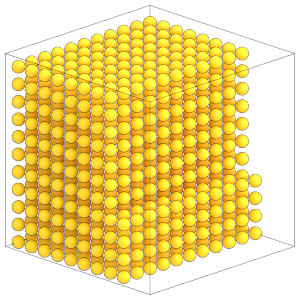

In [44]:
render(frame)

In [13]:
from pathlib import Path
import gsd.hoomd

# ============================================================
# Parameters used for naming
# ============================================================
BoxLength_str = f"{BoxLength:.1f}"
rho_str = f"{rho:.1f}"

# ============================================================
# Folder structure
# ============================================================
base_folder = Path("Simple_Cubic_Lattice")
box_folder = base_folder / f"BoxLength_{BoxLength_str}"
rho_folder = box_folder / f"rho_{rho_str}"

rho_folder.mkdir(parents=True, exist_ok=True)

# ============================================================
# Save file
# ============================================================
filename = rho_folder / "lattice.gsd"

if filename.exists():
    print(f"{filename} already exists — not overwriting.")
else:
    with gsd.hoomd.open(name=str(filename), mode="x") as f:
        f.append(frame)
    print(f"Saved lattice to {filename}")

Saved lattice to Simple_Cubic_Lattice/BoxLength_20.0/rho_0.6/lattice.gsd


Advisor method:
----------------------------
Target BoxLength = 15
Target rho = 0.3
Derived cell spacing = 1.4938015821857216
Number of particles = 1000
Actual rho = 0.2962962962962963
Density error = -0.003703703703703709


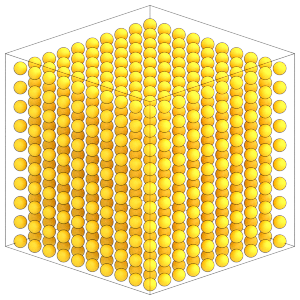

In [45]:
# ============================================================
# Advisor-style cubic lattice: build and render for comparison
# ============================================================

import numpy as np

def FillBoxCubicLattice(xlim, ylim, zlim, rho):
    cellsize = rho**(-1.0 / 3.0)

    nx = int(np.floor((xlim[1] - xlim[0]) / cellsize))
    ny = int(np.floor((ylim[1] - ylim[0]) / cellsize))
    nz = int(np.floor((zlim[1] - zlim[0]) / cellsize))

    xoffset = xlim[0] + 0.5 * ((xlim[1] - xlim[0]) - cellsize * nx)
    yoffset = ylim[0] + 0.5 * ((ylim[1] - ylim[0]) - cellsize * ny)
    zoffset = zlim[0] + 0.5 * ((zlim[1] - zlim[0]) - cellsize * nz)

    xvec = cellsize * np.arange(nx, dtype=np.float64) + xoffset
    yvec = cellsize * np.arange(ny, dtype=np.float64) + yoffset
    zvec = cellsize * np.arange(nz, dtype=np.float64) + zoffset

    positions = np.zeros((nx * ny * nz, 3), dtype=np.float64)
    pos = positions.reshape((nx, ny, nz, 3))

    pos[:, :, :, 0] = xvec[:, None, None]
    pos[:, :, :, 1] = yvec[None, :, None]
    pos[:, :, :, 2] = zvec[None, None, :]

    return positions

# Build lattice
positions_new = FillBoxCubicLattice(
    xlim=[-BoxLength / 2, BoxLength / 2],
    ylim=[-BoxLength / 2, BoxLength / 2],
    zlim=[-BoxLength / 2, BoxLength / 2],
    rho=rho
)

# Create frame
frame_new = gsd.hoomd.Frame()
frame_new.particles.N = len(positions_new)
frame_new.particles.types = ["A"]
frame_new.particles.position = positions_new
frame_new.particles.typeid = [0] * len(positions_new)
frame_new.configuration.box = [BoxLength, BoxLength, BoxLength, 0, 0, 0]

# ============================================================
# Print diagnostics
# ============================================================

actual_rho = len(positions_new) / BoxLength**3
cellsize = rho**(-1/3)

print("Advisor method:")
print("----------------------------")
print("Target BoxLength =", BoxLength)
print("Target rho =", rho)
print("Derived cell spacing =", cellsize)
print("Number of particles =", len(positions_new))
print("Actual rho =", actual_rho)
print("Density error =", actual_rho - rho)

# Render
render(frame_new)

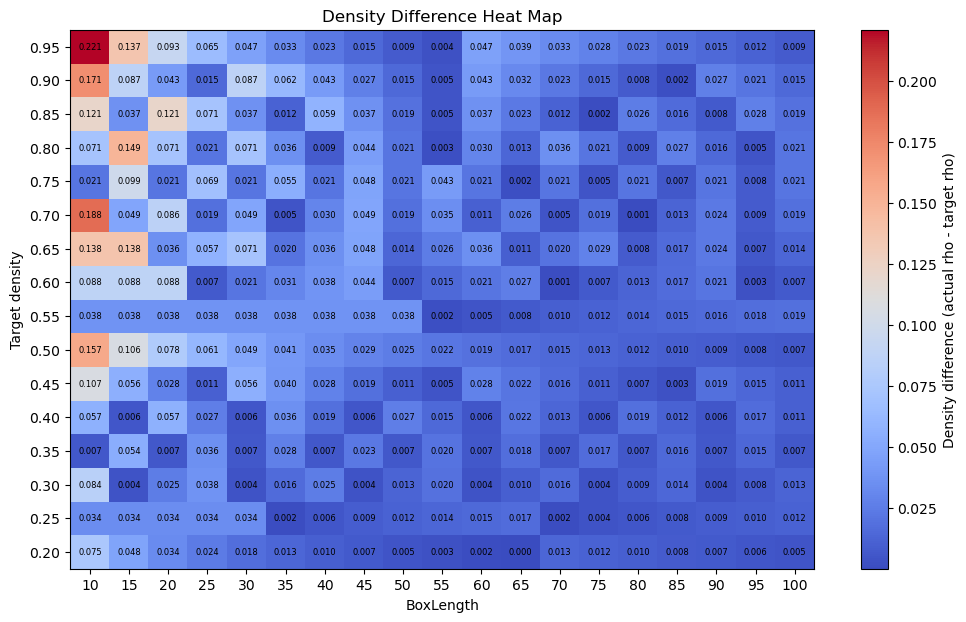

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def FillBoxCubicLattice(xlim, ylim, zlim, rho):
    cellsize = rho**(-1.0 / 3.0)

    nx = int(np.floor((xlim[1] - xlim[0]) / cellsize))
    ny = int(np.floor((ylim[1] - ylim[0]) / cellsize))
    nz = int(np.floor((zlim[1] - zlim[0]) / cellsize))

    xoffset = xlim[0] + 0.5 * ((xlim[1] - xlim[0]) - cellsize * nx)
    yoffset = ylim[0] + 0.5 * ((ylim[1] - ylim[0]) - cellsize * ny)
    zoffset = zlim[0] + 0.5 * ((zlim[1] - zlim[0]) - cellsize * nz)

    xvec = cellsize * np.arange(nx, dtype=np.float64) + xoffset
    yvec = cellsize * np.arange(ny, dtype=np.float64) + yoffset
    zvec = cellsize * np.arange(nz, dtype=np.float64) + zoffset

    positions = np.zeros((nx * ny * nz, 3), dtype=np.float64)
    pos = positions.reshape((nx, ny, nz, 3))

    pos[:, :, :, 0] = xvec[:, None, None]
    pos[:, :, :, 1] = yvec[None, :, None]
    pos[:, :, :, 2] = zvec[None, None, :]

    return positions

# Axes values
box_lengths = np.arange(10, 101, 5)          # 10,15,...,100
target_rhos = np.arange(0.2, 1.0, 0.05)      # 0.20,0.25,...,0.95

density_diff = np.zeros((len(target_rhos), len(box_lengths)))

for i, rho in enumerate(target_rhos):
    for j, BoxLength in enumerate(box_lengths):
        positions = FillBoxCubicLattice(
            xlim=[-BoxLength / 2, BoxLength / 2],
            ylim=[-BoxLength / 2, BoxLength / 2],
            zlim=[-BoxLength / 2, BoxLength / 2],
            rho=rho
        )

        actual_rho = len(positions) / BoxLength**3
        density_diff[i, j] = abs(actual_rho - rho)

plt.figure(figsize=(12, 7))
im = plt.imshow(
    density_diff,
    origin="lower",
    aspect="auto",
    extent=[
        box_lengths[0]-2.5, box_lengths[-1]+2.5,
        target_rhos[0]-0.025, target_rhos[-1]+0.025
    ],
    cmap="coolwarm"
)

plt.colorbar(im, label="Density difference (actual rho - target rho)")
plt.xlabel("BoxLength")
plt.ylabel("Target density")
plt.title("Density Difference Heat Map")

plt.xticks(box_lengths)
plt.yticks(target_rhos)

# annotate values
for i, rho in enumerate(target_rhos):
    for j, BoxLength in enumerate(box_lengths):
        plt.text(
            BoxLength,
            rho,
            f"{density_diff[i, j]:.3f}",
            ha="center",
            va="center",
            fontsize=6
        )

plt.show()